In [1]:
import torch
import glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
# from models.dylvvit import LVViTDiffPruning
from models.dyvit import VisionTransformerDiffPruning

/home/ljmarten/miniconda3/envs/dyvit/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# build transforms
from torchvision import datasets, transforms
from timm.data.constants import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD

t_resize_crop = transforms.Compose([
    transforms.Resize(256, interpolation=3),
    transforms.CenterCrop(224),
])

t_to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD),
])

/home/ljmarten/miniconda3/envs/dyvit/lib/python3.7/site-packages/torchvision/transforms/transforms.py:330: UserWarning: Argument 'interpolation' of type int is deprecated since 0.13 and will be removed in 0.15. Please use InterpolationMode enum.
  "Argument 'interpolation' of type int is deprecated since 0.13 and will be removed in 0.15. "


In [ ]:
# # build model
# BASE_RATE = 0.7
# KEEP_RATE = [BASE_RATE, BASE_RATE ** 2, BASE_RATE ** 3]
# PRUNING_LOC = [5, 10, 15]
# CKPT_PATH = 'checkpoints/dynamic-vit_lv-m_r0.7.pth'

# model = LVViTDiffPruning(
#     patch_size=16, embed_dim=512, depth=20, num_heads=8, mlp_ratio=3.,
#     p_emb='4_2',skip_lam=2., return_dense=True, mix_token=True,
#     pruning_loc=PRUNING_LOC, token_ratio=KEEP_RATE, viz_mode=True,
# )

# checkpoint = torch.load(CKPT_PATH, map_location='cpu')['model']
# model.load_state_dict(checkpoint)

In [7]:
BASE_RATE = 0.5
KEEP_RATE = [BASE_RATE, BASE_RATE ** 2, BASE_RATE ** 3]
PRUNING_LOC = [3, 6, 9]
# CKPT_PATH = 'checkpoints/dvit-deit-s-384_r0.7.pth'
# CKPT_PATH = "logs/dvit-deit-s-224_r0.7_rkt/checkpoint-best.pth"
CKPT_PATH = "logs/dvit_deit-s-224_r0.5/checkpoint-best.pth"

model = VisionTransformerDiffPruning(
    patch_size=16, embed_dim=384, depth=12, num_heads=6, mlp_ratio=4, qkv_bias=True, 
    pruning_loc=PRUNING_LOC, token_ratio=KEEP_RATE, distill=True, viz_mode=True,
)

checkpoint = torch.load(CKPT_PATH, map_location='cpu')['model']
model.load_state_dict(checkpoint)

## diff vit pruning method


<All keys matched successfully>

In [14]:
def get_keep_indices(decisions):
    # print("decisions: ", decisions)
    keep_indices = []
    for i in range(3):
        if i == 0:
            keep_indices.append(decisions[i])
        else:
            keep_indices.append(keep_indices[-1][decisions[i]])
        print(keep_indices)
    return keep_indices

def gen_masked_tokens(tokens, indices, alpha=0.2):
    indices = [i for i in range(196) if i not in indices]
    tokens = tokens.copy()
    tokens[indices] = alpha * tokens[indices] + (1 - alpha) * 255
    return tokens

def recover_image(tokens):
    # image: (C, 196, 16, 16)
    image = tokens.reshape(14, 14, 16, 16, 3).swapaxes(1, 2).reshape(224, 224, 3)
    return image

def gen_visualization(image, decisions):
    keep_indices = get_keep_indices(decisions)
    image = np.asarray(image)
    image_tokens = image.reshape(14, 16, 14, 16, 3).swapaxes(1, 2).reshape(196, 16, 16, 3)

    stages = [
        recover_image(gen_masked_tokens(image_tokens, keep_indices[i]))
        for i in range(3)
    ]
    viz = np.concatenate([image] + stages, axis=1)
    return viz

In [ ]:
def gen_masked_tokens(tokens, keep_indices, alpha=0.2):
    tokens = tokens.copy()

    mask = np.ones(len(tokens), dtype=bool)
    mask[keep_indices] = False

    tokens[mask] = alpha * tokens[mask] + (1 - alpha) * 255
    return tokens


def recover_image(tokens):
    return (
        tokens.reshape(14, 14, 16, 16, 3)
        .swapaxes(1, 2)
        .reshape(224, 224, 3)
    )


def gen_visualization(image, decisions):
    image = np.asarray(image)

    image_tokens = (
        image.reshape(14, 16, 14, 16, 3)
        .swapaxes(1, 2)
        .reshape(196, 16, 16, 3)
    )

    stages = [
        recover_image(gen_masked_tokens(image_tokens, d))
        for d in decisions
    ]

    return np.concatenate([image] + stages, axis=1)

In [5]:
import matplotlib as mpl

# To LaTeX
mpl.rcParams.update({
    "text.usetex": True,       # Usa LaTeX para todo el texto
    "font.family": "serif",    # Fuente tipo serif, igual que LaTeX
    "font.size": 22,         # Tamaño de fuente general
    "axes.labelsize": 22,      # Tamaño de etiquetas de ejes
    "xtick.labelsize": 8,      # Tamaño de ticks
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.titlesize": 12     # Tamaño del título
})

Visualizing imgs/1.jpg
3 1 torch.Size([1, 98]) torch.Size([1, 49]) torch.Size([1, 24])
(98,) (49,) (24,)
[array([ 39,  25,  36,  75, 176,  37,  52,  24,  58, 159,  97,  11,  63,
        74,  72,  20,  59,  73,  66,  84,  44,  51, 165, 130,  68, 122,
       186,   2,  10,  85,  98, 121,  55, 162, 149,  53, 166, 150,  86,
        62,  31, 153, 111, 190, 101,  67, 180,  42, 161,  28, 158, 178,
        76, 164,  82, 141,   7,  70, 102,  83,  13,  40,  35, 151,   9,
        64, 137, 139,  71,  87,   4, 124,  34,  41, 110,  96,  12,  54,
        27, 171, 163, 167, 112, 179,  78, 152,  47, 125, 194,  95,  81,
       140, 123, 148, 128, 100,  29,  21])]
[array([ 39,  25,  36,  75, 176,  37,  52,  24,  58, 159,  97,  11,  63,
        74,  72,  20,  59,  73,  66,  84,  44,  51, 165, 130,  68, 122,
       186,   2,  10,  85,  98, 121,  55, 162, 149,  53, 166, 150,  86,
        62,  31, 153, 111, 190, 101,  67, 180,  42, 161,  28, 158, 178,
        76, 164,  82, 141,   7,  70, 102,  83,  13,  40, 

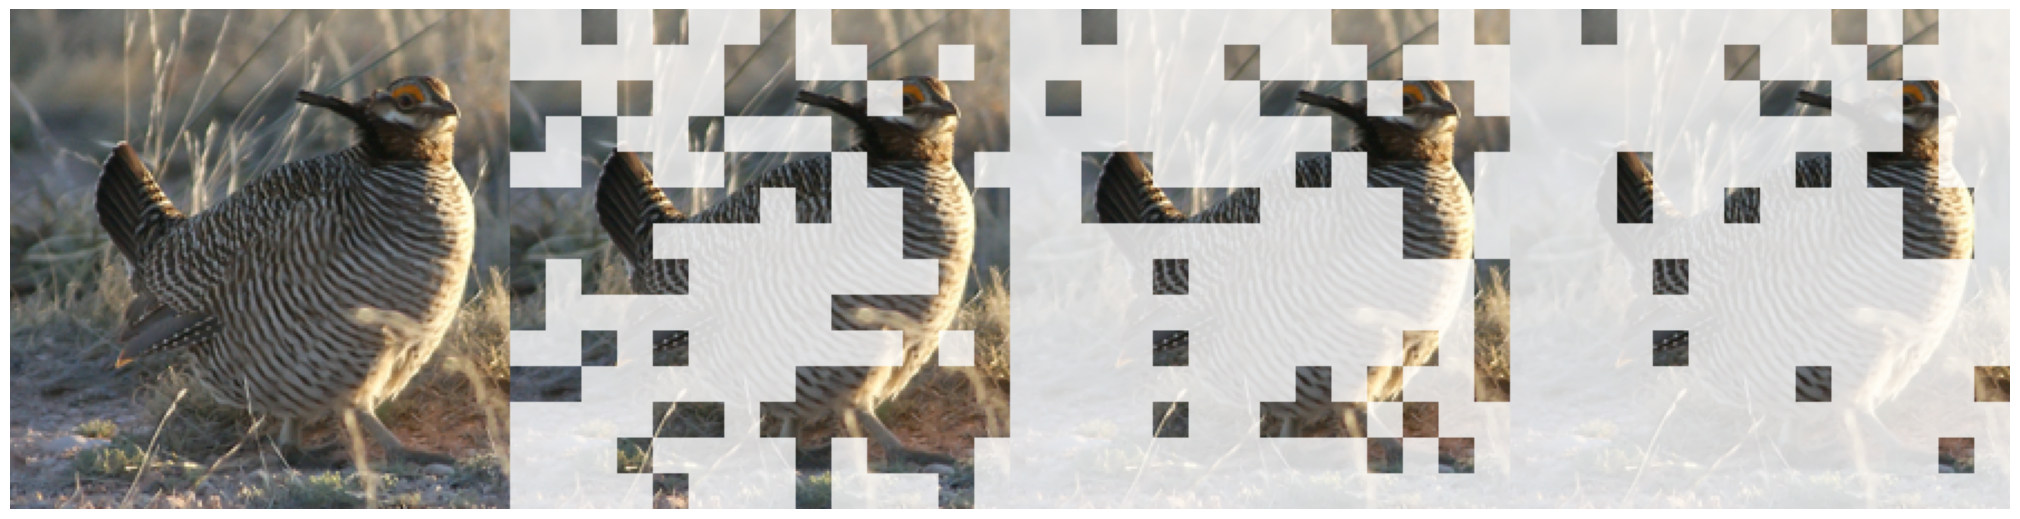

In [15]:
# visualization
# use a random image from IMAGE_ROOT

IMAGE_ROOT = 'imgs'
image_paths = sorted(glob.glob(f'imgs/*.jpg'))
idx = 0
image_path = image_paths[idx]
print('Visualizing', image_path)
image = Image.open(image_path)

image = t_resize_crop(image)
im_tensor = t_to_tensor(image).unsqueeze(0)

device = 'cpu'
model.to(device)
model.eval()
im_tensor = im_tensor.to(device)
with torch.cuda.amp.autocast():
    output, decisions = model(im_tensor)
    print(len(decisions), len(decisions[0]), decisions[0][0].shape, decisions[1][0].shape, decisions[2][0].shape)
decisions = [decisions[i][0][0].cpu().numpy() for i in range(3)]
print(decisions[0].shape, decisions[1].shape, decisions[2].shape)
viz = gen_visualization(image, decisions)

plt.figure(figsize=(20, 5))
plt.gca().set_axis_off()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.margins(0, 0)
plt.gca().xaxis.set_major_locator(plt.NullLocator())
plt.gca().yaxis.set_major_locator(plt.NullLocator())
# plt.axis('off')
plt.imshow(viz)
plt.savefig(f"imgs/{idx+1}.jpeg", bbox_inches="tight", pad_inches=0)
# plt.cla()
